# Day 32 - Customer Churn Model Comparison

## 학습 주제

동일한 고객 이탈 데이터를 이용하여 지금까지 학습한 분류 모델을 동일한 기준으로 비교한다.

비교 대상:

- Majority Class Baseline
- Logistic Regression
- Decision Tree
- Random Forest

모델 점수뿐 아니라 과적합 가능성, 설명 가능성, 업무 활용성을 함께 고려한다.

## 분석 질문

1. 각 모델은 단순 Baseline보다 나은가?
2. Accuracy, Precision, Recall, F1은 모델마다 어떻게 다른가?
3. Train과 Test 성능 차이는 어떻게 다른가?
4. 더 복잡한 모델이 항상 더 높은 성능을 보이는가?
5. 성능이 비슷하다면 어떤 기준으로 모델을 선택해야 하는가?
6. 동일한 평가 지표를 가진 모델이 동일한 고객을 예측하는가?

## 모델 비교 원칙

모델을 공정하게 비교하기 위해 다음 조건을 동일하게 유지한다.

- 동일한 원본 데이터
- 동일한 Feature
- 동일한 Target
- 동일한 Train/Test 분할
- 동일한 평가 지표

이번 비교에서는 Accuracy뿐 아니라 Precision, Recall, F1과 Confusion Matrix를 함께 확인한다.

현재 Test 데이터는 이전 Day에서 이미 반복적으로 확인했으므로 이번 결과를 최종 일반화 성능으로 해석하지 않는다.

In [ ]:
# 라이브러리
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [2]:
# Path 설정
project_root = Path.cwd().parent

input_path = (
    project_root
    / "data"
    / "raw"
    / "day29_customer_churn_classification.csv"
)

output_dir = (
    project_root
    / "outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(
    input_path
)

print(
    output_dir
)

d:\Study\Projects\00_foundation_review\data\raw\day29_customer_churn_classification.csv
d:\Study\Projects\00_foundation_review\outputs


In [4]:
# Data 불러오기
df = pd.read_csv(
    input_path
)

print(df.head())
print(df.shape)
print(df["next_30d_churn"].value_counts())

   customer_id  login_days_30d  order_count_90d  support_tickets_90d  \
0            1               2                3                    5   
1            2              23                4                    3   
2            3              20                3                    3   
3            4              13                1                    5   
4            5              13                1                    0   

   membership_months  days_since_last_login  billing_issue_count_90d  \
0                 36                     11                        1   
1                 20                     38                        0   
2                 58                     28                        1   
3                 44                     15                        0   
4                 45                     28                        1   

   next_30d_churn  
0               1  
1               1  
2               0  
3               0  
4               1  
(800, 8)
next_

In [5]:
# feature, target 나누기

features = [
    "login_days_30d",
    "order_count_90d",
    "support_tickets_90d",
    "membership_months",
    "days_since_last_login",
    "billing_issue_count_90d"
]

X = df[
    features
]

y = df[
    "next_30d_churn"
]

In [7]:
# Train/Test 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.25,
    random_state = 42,
    stratify = y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(600, 6)
(200, 6)
next_30d_churn
0    358
1    242
Name: count, dtype: int64
next_30d_churn
0    120
1     80
Name: count, dtype: int64


## Baseline

Train 데이터에서 가장 많은 클래스를 모든 고객에게 예측하는 단순 Baseline을 만든다.

복잡한 머신러닝 모델은 최소한 이 단순한 기준보다 의미 있는 성능을 보여야 한다.

In [15]:
majority_class = (
    y_train
    .mode()[0]
)

baseline_train_prediction = (
    [majority_class]
    * len(y_train)
)

baseline_test_prediction = (
    [majority_class]
    * len(y_test)
)

baseline_train_accuracy = accuracy_score(
    y_train,
    baseline_train_prediction
)

baseline_test_accuracy = accuracy_score(
    y_test,
    baseline_test_prediction
)

baseline_precision = precision_score(
    y_test,
    baseline_test_prediction,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_test_prediction
)

baseline_f1 = f1_score(
    y_test,
    baseline_test_prediction,
    zero_division=0
)

print(
    f"Train Accuracy: {baseline_train_accuracy:.3f}"
)

print(
    f"Test Accuracy: {baseline_test_accuracy:.3f}"
)

print(
    f"Precision: {baseline_precision:.3f}"
)

print(
    f"Recall: {baseline_recall:.3f}"
)

print(
    f"F1: {baseline_f1:.3f}"
)

Train Accuracy: 0.597
Test Accuracy: 0.600
Precision: 0.000
Recall: 0.000
F1: 0.000


In [16]:
# 모델 준비
models = {
    "logistic_regression" : LogisticRegression(),
    "decision_tree" : DecisionTreeClassifier(
        max_depth = 4,
        random_state = 42
    ),
    "random_forest" : RandomForestClassifier(
        n_estimators = 200,
        max_depth = 6,
        random_state = 42
    )
}

In [20]:
comparison_rows = [] # 평가지표 저장
confusion_rows = [] # TN/FP/FN/TP 저장
predictions = {} # 고객별 모델 예측 저장

In [22]:
# Baseline 저장
baseline_confusion = confusion_matrix(
    y_test,
    baseline_test_prediction
)

comparison_rows.append(
    {
        "model" : "baseline",
        "train_accuracy" : baseline_train_accuracy,
        "test_accuracy" : baseline_test_accuracy,
        "precision": baseline_precision,
        "recall": baseline_recall,
        "f1": baseline_f1,        
    }
)

confusion_rows.append(
    {
        "model": "baseline",
        "tn": baseline_confusion[0, 0],
        "fp": baseline_confusion[0, 1],
        "fn": baseline_confusion[1, 0],
        "tp": baseline_confusion[1, 1],
    }
)

predictions[
    "baseline"
] = baseline_test_prediction

In [24]:
for model_name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    train_prediction = model.predict(
        X_train
    )

    test_prediction = model.predict(
        X_test
    )

    train_accuracy = accuracy_score(
        y_train,
        train_prediction
    )

    test_accuracy = accuracy_score(
        y_test,
        test_prediction
    )

    precision = precision_score(
        y_test,
        test_prediction
    )

    recall = recall_score(
        y_test,
        test_prediction
    )

    f1 = f1_score(
        y_test,
        test_prediction
    )

    confusion = confusion_matrix(
        y_test,
        test_prediction
    )

    comparison_rows.append(
        {
            "model": model_name,
            "train_accuracy": train_accuracy,
            "test_accuracy": test_accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }
    )

    confusion_rows.append(
        {
            "model": model_name,
            "tn": confusion[0, 0],
            "fp": confusion[0, 1],
            "fn": confusion[1, 0],
            "tp": confusion[1, 1],
        }
    )

    predictions[
        model_name
    ] = test_prediction


In [34]:
# 모델 비교표
comparison_df = pd.DataFrame(
    comparison_rows
)
comparison_df

,model,train_accuracy,test_accuracy,precision,recall,f1
0,baseline,0.596667,0.600,0.000000,0.000,0.000000
1,logistic_regression,0.708333,0.725,0.666667,0.625,0.645161
2,decision_tree,0.731667,0.605,0.506329,0.500,0.503145
3,random_forest,0.836667,0.725,0.666667,0.625,0.645161


In [26]:
confusion_summary_df = pd.DataFrame(
    confusion_rows
)

print(
    confusion_summary_df
)

                 model   tn  fp  fn  tp
0             baseline  120   0  80   0
1  logistic_regression   95  25  30  50
2        decision_tree   81  39  40  40
3        random_forest   95  25  30  50


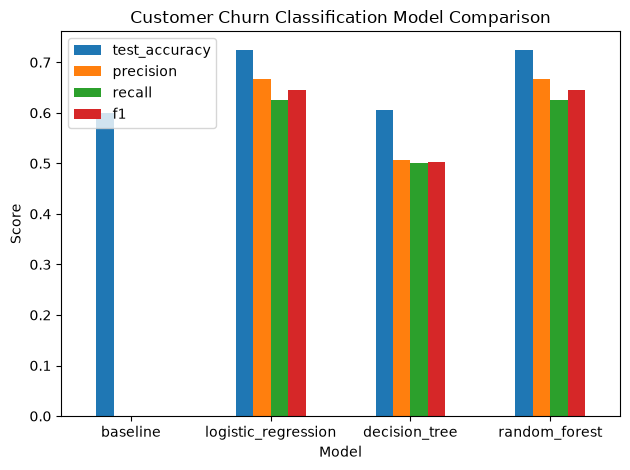

In [30]:
figure_path = (
    output_dir
    / "customer_churn_model_comparison.png"
)

comparison_df.plot.bar(
    x="model",
    y=[
        "test_accuracy",
        "precision",
        "recall",
        "f1",
    ]
)

plt.title(
    "Customer Churn Classification Model Comparison"
)

plt.xlabel(
    "Model"
)

plt.xticks(
    rotation = 0
)

plt.ylabel(
    "Score"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Customer-Level Prediction Comparison

모델의 전체 평가 지표가 같더라도
개별 고객에 대한 예측까지 같다는 뜻은 아니다.

Logistic Regression과 Random Forest의 고객별 예측을 비교한다.

In [31]:
prediction_df = pd.DataFrame(
    {
        "customer_id": df.loc[
            X_test.index,
            "customer_id"
        ],
        "actual_churn": y_test,
        "baseline_prediction": predictions[
            "baseline"
        ],
        "logistic_prediction": predictions[
            "logistic_regression"
        ],
        "decision_tree_prediction": predictions[
            "decision_tree"
        ],
        "random_forest_prediction": predictions[
            "random_forest"
        ],
    }
)

print(
    prediction_df.head(
        10
    )
)

     customer_id  actual_churn  baseline_prediction  logistic_prediction  \
677          678             0                    0                    1   
403          404             0                    0                    0   
206          207             1                    0                    0   
795          796             0                    0                    0   
788          789             0                    0                    0   
461          462             0                    0                    1   
488          489             0                    0                    1   
595          596             0                    0                    0   
681          682             0                    0                    1   
22            23             1                    0                    1   

     decision_tree_prediction  random_forest_prediction  
677                         1                         1  
403                         1                  

In [32]:
logistic_random_forest_disagreement = (
    prediction_df[
        "logistic_prediction"
    ]
    != prediction_df[
        "random_forest_prediction"
    ]
).sum()

print(
    "Logistic Regression과 Random Forest의 "
    "예측이 다른 고객 수:",
    logistic_random_forest_disagreement
)

Logistic Regression과 Random Forest의 예측이 다른 고객 수: 28


In [33]:
comparison_path = (
    output_dir
    / "customer_churn_model_comparison_metrics.csv"
)

confusion_path = (
    output_dir
    / "customer_churn_model_confusion_summary.csv"
)

prediction_path = (
    output_dir
    / "customer_churn_model_predictions.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

confusion_summary_df.to_csv(
    confusion_path,
    index=False
)

prediction_df.to_csv(
    prediction_path,
    index=False
)

print(
    comparison_path
)

print(
    confusion_path
)

print(
    prediction_path
)

d:\Study\Projects\00_foundation_review\outputs\customer_churn_model_comparison_metrics.csv
d:\Study\Projects\00_foundation_review\outputs\customer_churn_model_confusion_summary.csv
d:\Study\Projects\00_foundation_review\outputs\customer_churn_model_predictions.csv


## 최종 해석

### Baseline

- Test Accuracy: 0.600
- Precision: 0
- Recall: 0
- F1: 0

다수 클래스만 예측하는 Baseline은 일정 수준의 Accuracy를 보일 수 있지만
실제 이탈 고객을 탐지하지 못하므로 업무적으로 유용한 분류 모델이라고 볼 수 없다.

### Logistic Regression

- Test Accuracy: 0.725
- Precision: 0.667
- Recall: 0.625
- F1: 0.645

Baseline보다 분류 성능이 개선되었으며,
비교적 단순하고 설명 가능한 분류 모델이다.

### Decision Tree

- Test Accuracy: 0.605
- Precision: 0.506
- Recall: 0.500
- F1: 0.503

이번 데이터에서는 Logistic Regression과 Random Forest보다
낮은 Test 성능을 보였다.

### Random Forest

- Test Accuracy: 0.725
- Precision: 0.667
- Recall: 0.625
- F1: 0.45

Random Forest는 여러 Decision Tree를 결합하는 복잡한 모델이지만
이번 데이터에서는 Logistic Regression보다 더 높은 Test 성능을 보이지 않았다.

### 모델 비교

이번 학습용 데이터에서는 Logistic Regression과 Random Forest가
동일한 주요 평가 지표를 보였다.

성능 차이가 없다면 더 단순하고 설명하기 쉬운 Logistic Regression을
우선 후보로 고려할 수 있다.

그러나 두 모델의 전체 평가 지표가 동일하더라도
고객별 예측은 서로 다를 수 있음을 확인했다.

### 중요한 한계

Day 29~31에서 Test 데이터를 이미 반복적으로 확인했으므로
현재 결과를 최종 모델 선택이나 실제 일반화 성능으로 해석해서는 안 된다.

실제 머신러닝 모델 선택에서는
Train / Validation / Test 구조 또는 Cross Validation을 이용하여
모델 선택과 최종 평가를 분리해야 한다.